In [1]:
#data visualization 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from matplotlib import pyplot
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_pacf
from gdeep.utility.extended_persistence import graph_extended_persistence_hks 

#graph theory 
import networkx as nx
import numpy as np

#tda
from gtda.homology import VietorisRipsPersistence,FlagserPersistence,EuclideanCechPersistence
from gtda.diagrams import PersistenceEntropy

#tqdm
from tqdm import tqdm

#for copy
import copy

#pd np
import pandas as pd 
import numpy as np 

#stat
import scipy.stats

/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


No TPUs...


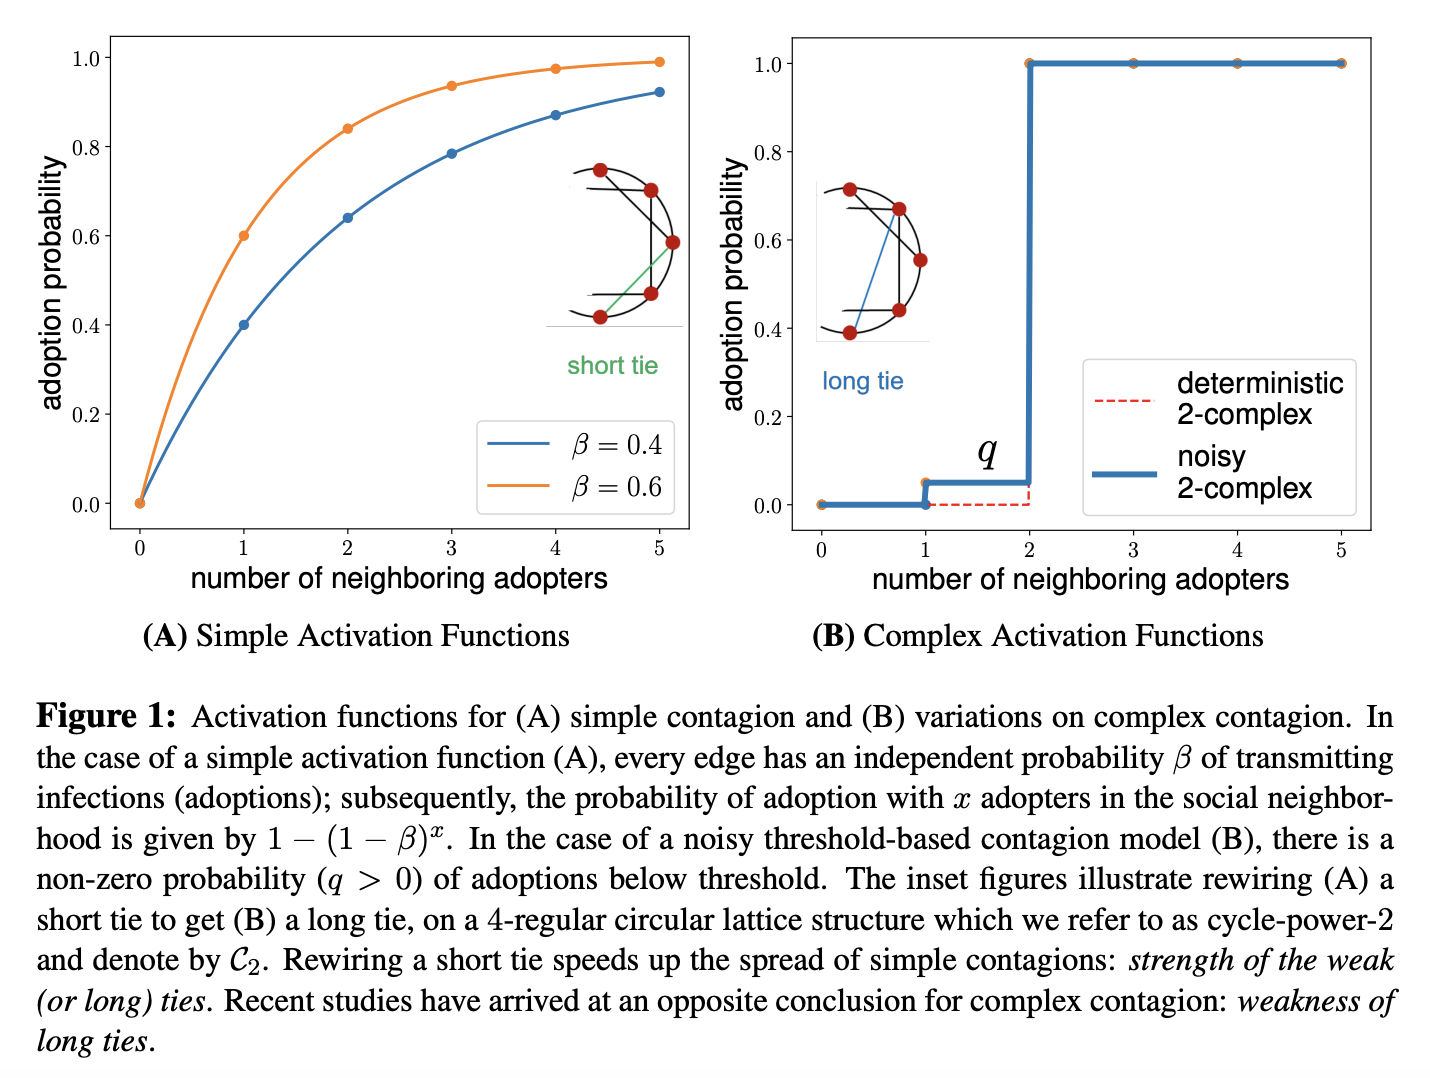

## Infection step: 
 **Here, we implemented a step of infection, which means that each node $i$ with at least $th_i$ infected neighbours will be infected here.** 


In [2]:
def do_transfers(n,A,list_inf,simple_with_pr=False,th=2, betha = 0.5,q_complex=0.1):
    
    #simple with probablity
    if simple_with_pr:
        new_infected_marker = False
        new_infected_nodes = [] 
        for i in range(n):
            if list_inf[i] == 1:
                continue
            else:
                edges = np.where(A[i] == 1)[0]
                n_inf_nbr = 0 
                for j in edges:
                    if list_inf[j] == 1:
                        n_inf_nbr += 1
                pr_got_infected = 1 - (1-betha)**n_inf_nbr
                if np.random.uniform(0,1) < pr_got_infected:
                    new_infected_marker = True
                    new_infected_nodes.append(i)

        for i in new_infected_nodes:
            list_inf[i] = 1
        return new_infected_marker, list_inf
        
    #other cases
    else:
        new_infected_marker = False
        new_infected_nodes = [] 
        for i in range(n):
            if list_inf[i] == 1:
                continue
            else:
                edges = np.where(A[i] == 1)[0]
                n_inf_nbr = 0 
                for j in edges:
                    if list_inf[j] == 1:
                        n_inf_nbr += 1
                infection_done = False
                infection_done == n_inf_nbr > th
                if n_inf_nbr == th - 1:
                    if np.random.uniform(0,1) < q_complex:
                        infection_done = True    
                if infection_done:
                    new_infected_nodes.append(i)
                    new_infected_marker = True
        for i in new_infected_nodes:
            list_inf[i] = 1
    return new_infected_marker, list_inf

In [70]:
#iterations of infection 


# complex_list_VR1 = []
# simple_list_VR1 = [] 

# complex_list_ninf = [] 
# simple_list_ninf = [] 

# complex_list_EPH1 = []
# simple_list_EPH1 = [] 

# complex_list_EPH0 = []
# simple_list_EPH0 = [] 

# complex_list_EPH2 = []
# simple_list_EPH2 = [] 


# complex_list_EPH3 = []
# simple_list_EPH3 = [] 

# simple_n_cliques3 = [] 
# complex_n_cliques3 = [] 

# simple_n_cliques4 = [] 
# complex_n_cliques4 = [] 


# simple_deg_order = [] 
# complex_deg_order = [] 


n = 500 
n_subgraph = 500
pr_initial_infected = 0.1
G_fixed = nx.barabasi_albert_graph(n,1)

for iteration in tqdm(range(100)):
    #initial graph and intial infected nodes

    list_inf = [1 if pr_initial_infected >= np.random.uniform(0,1) else 0 for i in range(n)]

    #creating a copy of initial graph and its infected nodes 
    G_copy = copy.deepcopy(G_fixed)
    list_inf_copy = copy.deepcopy(list_inf)
    
   
    #Complex Contagion
    new_infected_nodes = True
    tim_curr = 0

    G = copy.deepcopy(G_fixed)
    list_inf = copy.deepcopy(list_inf_copy)
    
    A = nx.to_numpy_array(G)

    step_of_infection_per_node = [None for i in range(n)]
    #performing iterations 
#     while tim_curr <= 3:
    while new_infected_nodes:
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(n,A,list_inf,simple_with_pr=False, th=2,q_complex=0.2)
    
        for nod_indx in range(len(list_inf)):
            if step_of_infection_per_node[nod_indx] == None and list_inf[nod_indx] == 1:
                step_of_infection_per_node[nod_indx] = tim_curr
                
    #classic approach 
    degrees_list = list(dict(G.subgraph([i for i in range(n_subgraph)]).degree).values())
    infection_order = np.array(step_of_infection_per_node[:n_subgraph],dtype=float)
    try:
        rho, p_value = scipy.stats.spearmanr(degrees_list, infection_order,nan_policy='omit')
    except:
        rho = 0
    complex_deg_order.append(rho)
    
    # adding all edges between infected vertices 
    for i in range(n):
        for j in range(n):
            if i != j:
                if list_inf[i] == 1 and list_inf[j] == 1:
                    G.add_edge(i,j)  
    #VR dim 1:
    #distance matrix 
    dis = nx.floyd_warshall_numpy(G.subgraph([i for i in range(n_subgraph)]))
    #VR PH 
#     ph = VietorisRipsPersistence(metric = "precomputed",homology_dimensions=[2])
#     VR = ph.fit_transform([dis])[0]
#     len_vr_dim1 = np.sum([1 if VR[i][2] == 2 else 0 for i in range(len(VR))])
#     complex_list_VR1.append(len_vr_dim1)
    #ratio of infected nodes 
    complex_list_ninf.append(np.sum(list_inf[:n_subgraph])/len(list_inf[:n_subgraph]))
    complex_n_cliques3.append(len(np.where(np.array([len(cl) for cl in list(nx.find_cliques(G.subgraph([i for i in range(n_subgraph)])))]) == 3)[0]))
    complex_n_cliques4.append(len(np.where(np.array([len(cl) for cl in list(nx.find_cliques(G.subgraph([i for i in range(n_subgraph)])))]) == 4)[0]))

    #extended persistent homology
    A = nx.to_numpy_array(G)
    ext_ph = graph_extended_persistence_hks(A)
    ext_ph = ext_ph.get_raw_data()
    ext_ph = ext_ph.numpy()
    dim1 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][3] == 1 else 0 for i in range(len(ext_ph))])
    dim0 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][2] == 1 else 0 for i in range(len(ext_ph))])
    dim2 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][4] == 1 else 0 for i in range(len(ext_ph))])
    dim3 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][5] == 1 else 0 for i in range(len(ext_ph))])

    complex_list_EPH1.append(dim1)
    complex_list_EPH0.append(dim0)
    complex_list_EPH2.append(dim2)
    complex_list_EPH3.append(dim3)
    

    
    ##-------------------------------------------------------------------------------------------

    #simple contagion
        
    G = copy.deepcopy(G_copy)
    list_inf = copy.deepcopy(list_inf_copy)
    list_inf_last_step = list_inf
    
    #probablisitc simple 
    new_infected_nodes = True
    tim_curr = 0

    A = nx.to_numpy_array(G)
    
    step_of_infection_per_node = [None for i in range(n)]

#     while tim_curr <= 3:
    while new_infected_nodes:
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(n,A,list_inf,simple_with_pr=True, betha=0.1)
        
        for nod_indx in range(len(list_inf)):
            if step_of_infection_per_node[nod_indx] == None and list_inf[nod_indx] == 1:
                step_of_infection_per_node[nod_indx] = tim_curr
    
    #classic approach 
    degrees_list = list(dict(G.subgraph([i for i in range(n_subgraph)]).degree).values())
    infection_order = np.array(step_of_infection_per_node[:n_subgraph],dtype=float)
    try:
        rho, p_value = scipy.stats.spearmanr(degrees_list, infection_order,nan_policy='omit')
    except:
        rho = 0
    simple_deg_order.append(rho)
        
    # adding all edges between infected vertices 
    for i in range(n):
        for j in range(n):
            if i != j:
                if list_inf[i] == 1 and list_inf[j] == 1:
                    G.add_edge(i,j)    
    #ratio of infected nodes 
    simple_list_ninf.append(np.sum(list_inf[:n_subgraph])/len(list_inf[:n_subgraph]))
    
    #VR dim 1:
    #distance matrix 
    dis = nx.floyd_warshall_numpy(G.subgraph([i for i in range(n_subgraph)]))
    #VR PH 
#     ph = VietorisRipsPersistence(metric = "precomputed",homology_dimensions=[2])
#     VR = ph.fit_transform([dis])[0]
#     len_vr_dim1 = np.sum([1 if VR[i][2] == 2 else 0 for i in range(len(VR))])
#     simple_list_VR1.append(len_vr_dim1)
    
    simple_n_cliques3.append(len(np.where(np.array([len(cl) for cl in list(nx.find_cliques(G.subgraph([i for i in range(n_subgraph)])))]) == 3)[0]))
    simple_n_cliques4.append(len(np.where(np.array([len(cl) for cl in list(nx.find_cliques(G.subgraph([i for i in range(n_subgraph)])))]) == 4)[0]))

    
    #extended persistent homology
    A = nx.to_numpy_array(G)
    ext_ph = graph_extended_persistence_hks(A)
    ext_ph = ext_ph.get_raw_data()
    ext_ph = ext_ph.numpy()
    dim1 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][3] == 1 else 0 for i in range(len(ext_ph))])
    dim0 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][2] == 1 else 0 for i in range(len(ext_ph))])
    dim2 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][4] == 1 else 0 for i in range(len(ext_ph))])
    dim3 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][5] == 1 else 0 for i in range(len(ext_ph))])


    simple_list_EPH1.append(dim1)
    simple_list_EPH0.append(dim0)
    simple_list_EPH2.append(dim2)
    simple_list_EPH3.append(dim3)

100%|██████████| 100/100 [14:10<00:00,  8.51s/it]


In [71]:
    A = nx.to_numpy_array(G)
    ext_ph = graph_extended_persistence_hks(A)
    ext_ph = ext_ph.get_raw_data()
    ext_ph = ext_ph.numpy()
    ext_ph

array([[0.3682639 , 0.3705538 , 1.        , 0.        , 0.        ,
        0.        ],
       [0.3682639 , 0.3705538 , 1.        , 0.        , 0.        ,
        0.        ],
       [0.3682639 , 0.3705538 , 1.        , 0.        , 0.        ,
        0.        ],
       ...,
       [0.36882478, 0.3705538 , 0.        , 0.        , 0.        ,
        1.        ],
       [0.36882478, 0.3705538 , 0.        , 0.        , 0.        ,
        1.        ],
       [0.3692104 , 0.3705538 , 0.        , 0.        , 0.        ,
        1.        ]], dtype=float32)

In [72]:
len(np.where(np.array([len(cl) for cl in list(nx.find_cliques(G.subgraph([i for i in range(n_subgraph)])))]) == 2)[0])

26

## Visualization 

1. Topological indicator

In [73]:
# import random
# import numpy
# from matplotlib import pyplot


# pyplot.hist(simple_list_VR1,  alpha=0.5, label='simple TDA')
# pyplot.hist(complex_list_VR1,  alpha=0.5, label='complex TDA')

# pyplot.legend(loc='upper right')
# pyplot.show()

2. n_infected nodes 

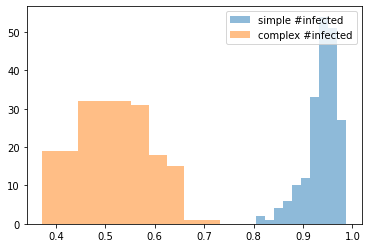

In [74]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_ninf,  alpha=0.5, label='simple #infected')
pyplot.hist(complex_list_ninf,  alpha=0.5, label='complex #infected')

pyplot.legend(loc='upper right')
pyplot.show()

3. EXPH dim 0

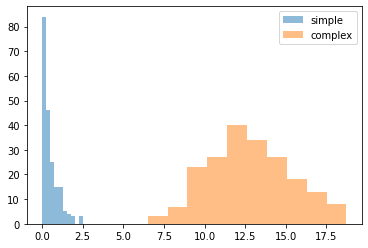

In [75]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH0,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH0,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

4. EXPH dim 1

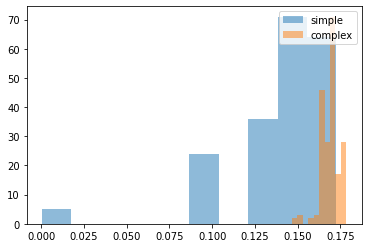

In [76]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH1,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH1,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

4. EXPH dim 2

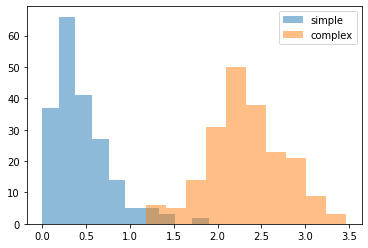

In [77]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH2,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH2,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

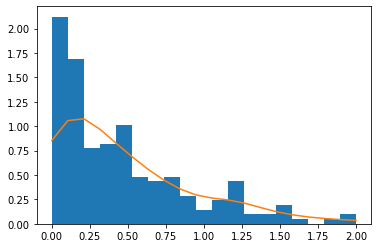

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

noise = simple_list_EPH0
density = stats.gaussian_kde(noise)
n, x, _ = plt.hist(noise, bins=np.linspace(0, 2, 20), 
                    density=True)  

# noise = complex_list_EPH0
# density = stats.gaussian_kde(noise)
# n, x, _ = plt.hist(noise, bins=np.linspace(-3, 3, 50), 
#                    histtype=u'step', density=True)
plt.plot(x, density(x))
plt.show()

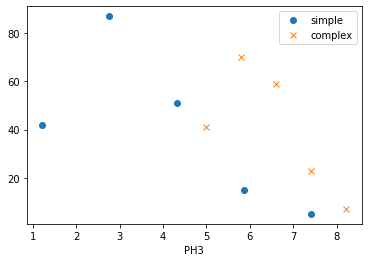

In [117]:
import numpy as np
from matplotlib import pyplot as pp

x = np.random.randn(10000)
counts,bin_edges = np.histogram(simple_list_EPH3,10)
bin_centres = (bin_edges[:-1] + bin_edges[1:])/2.
# err = np.random.rand(bin_centres.size)*100
pp.errorbar(bin_centres, counts, fmt='o',label='simple')

x = np.random.randn(10000)
counts,bin_edges = np.histogram(complex_list_EPH3,10)
bin_centres = (bin_edges[:-1] + bin_edges[1:])/2.
# err = np.random.rand(bin_centres.size)*100
pp.errorbar(bin_centres, counts, fmt='x',label='complex')

pyplot.legend(loc='upper right')
pp.xlabel(xlabel='PH3')
pp.show()


5. EXPH dim 3

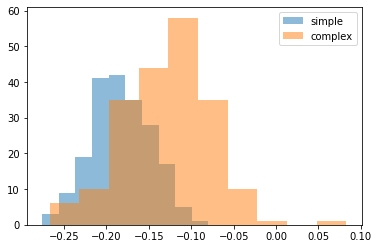

In [80]:
import random
import numpy
from matplotlib import pyplot



pyplot.hist(simple_deg_order,  alpha=0.5, label='simple')
pyplot.hist(complex_deg_order,  alpha=0.5, label='complex')
# pyplot.hist(14*(((np.array(simple_list_EPH3)/210)-16)/2.97),  alpha=0.5, label='simple_normalized')

pyplot.legend(loc='upper right')
pyplot.show()

6. Classic approach

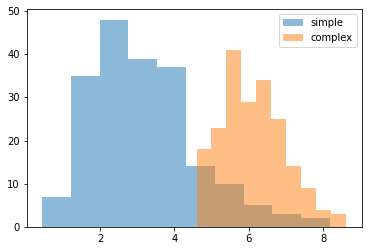

In [81]:
import random
import numpy
from matplotlib import pyplot



pyplot.hist(simple_list_EPH3,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH3,  alpha=0.5, label='complex')
# pyplot.hist(14*(((np.array(simple_list_EPH3)/210)-16)/2.97),  alpha=0.5, label='simple_normalized')

pyplot.legend(loc='upper right')
pyplot.show()

In [82]:
np.mean(simple_list_EPH3),np.mean(complex_list_EPH3),np.std(simple_list_EPH3),np.std(complex_list_EPH3)

(3.145085232704878, 6.129653988629579, 1.4115146009414685, 0.84866895476961)

6. n_cliques with 3 nodes

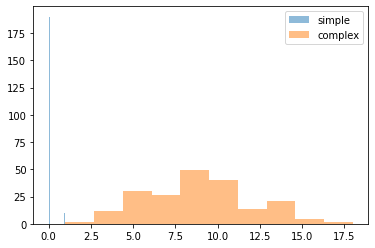

In [83]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_n_cliques3,  alpha=0.5, label='simple')
pyplot.hist(complex_n_cliques3,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

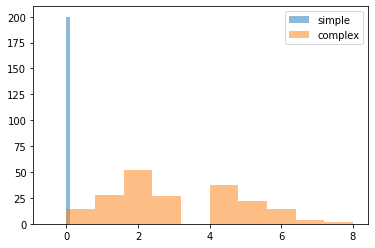

In [84]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_n_cliques4,  alpha=0.5, label='simple')
pyplot.hist(complex_n_cliques4,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

In [16]:
from scipy import stats
print(stats.ttest_ind(simple_list_VR1, complex_list_VR1))
print(stats.ttest_ind(simple_list_ninf, complex_list_ninf))

Ttest_indResult(statistic=nan, pvalue=nan)
Ttest_indResult(statistic=54.31630081806713, pvalue=6.7278550817040445e-121)


In [17]:
print(stats.ttest_ind(simple_list_EPH0, complex_list_EPH0))
print(stats.ttest_ind(simple_list_EPH1, complex_list_EPH1))
print(stats.ttest_ind(simple_list_EPH2, complex_list_EPH2))
print(stats.ttest_ind(simple_list_EPH3, complex_list_EPH3))

Ttest_indResult(statistic=-50.749543884458944, pvalue=1.9001563141848699e-115)
Ttest_indResult(statistic=-11.25136421166559, pvalue=5.0285472549653614e-23)
Ttest_indResult(statistic=-34.50031061355216, pvalue=1.1246110677508641e-85)
Ttest_indResult(statistic=-18.46608721573793, pvalue=6.224153395583519e-45)


In [18]:
print(stats.ttest_ind(np.nan_to_num(simple_deg_order),np.nan_to_num(complex_deg_order)))

Ttest_indResult(statistic=-8.692361520842462, pvalue=1.3459331449011244e-15)


# Results 

## parameters :

1. **when betha = 0.1 and th=2 and $q_{complex} = 0.1$:** 
**VR1:** pvalue=5.0306637010612946e-26 , **n_infected:** pvalue=1.925859689061716e-16

2. **when betha = 0.1 and th=2 and $q_{complex} = 0.2$:** 
**VR1:** pvalue= 8.690553060679639e-20, **n_infected:** pvalue=0.013435185290443854

# Using ML methods 

### creating data sets 

In [19]:
simples_df = pd.DataFrame()
simples_df['PH1'] = simple_list_VR1
simples_df['EXP0'] = simple_list_EPH0
simples_df['EXP1'] = simple_list_EPH1
simples_df['EXP2'] = simple_list_EPH2
simples_df['deg'] = simple_deg_order

simples_df['label'] = [0 for i in range(len(simples_df))]

In [20]:
complex_df = pd.DataFrame()
complex_df['PH1'] = complex_list_VR1
complex_df['EXP0'] = complex_list_EPH0
complex_df['EXP1'] = complex_list_EPH1
complex_df['EXP2'] = complex_list_EPH2
complex_df['deg'] = complex_deg_order

complex_df['label'] = [1 for i in range(len(complex_df))]

In [21]:
all_df = pd.concat([simples_df,complex_df])
all_df = all_df.sample(len(all_df))
all_df.fillna(0,inplace=True)

In [22]:
all_df.corr()

,PH1,EXP0,EXP1,EXP2,deg,label
PH1,NaN,NaN,NaN,NaN,NaN,NaN
EXP0,NaN,1.000000,0.647182,0.946531,0.532521,0.963644
EXP1,NaN,0.647182,1.000000,0.662970,0.336698,0.624504
EXP2,NaN,0.946531,0.662970,1.000000,0.499792,0.925946
deg,NaN,0.532521,0.336698,0.499792,1.000000,0.525550
label,NaN,0.963644,0.624504,0.925946,0.525550,1.000000


### Our model 

In [23]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

X = all_df[['EXP2']]
y = all_df['label']

X_train, y_train = X[80:], y[80:]
X_test, y_test = X[:80],y[:80] 

In [24]:
clf.fit(X_train,y_train)
y_hat = clf.predict(X_test)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.98      1.00      0.99        45

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



## Baseline

In [26]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

X = all_df[['deg']]
y = all_df['label']

X_train, y_train = X[80:], y[80:]
X_test, y_test = X[:80],y[:80] 

In [27]:
clf.fit(X_train,y_train)
y_hat = clf.predict(X_test)

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.59      0.69      0.63        35
           1       0.72      0.62      0.67        45

    accuracy                           0.65        80
   macro avg       0.65      0.65      0.65        80
weighted avg       0.66      0.65      0.65        80

